In [11]:
from graphdatascience import GraphDataScience
# Neo4j connection parameters
NEO4J_URI = "bolt://localhost:49879" # Update this if your port is different
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "itlawskg"

# Use Neo4j URI and credentials according to your setup
# NEO4J_URI could look similar to "bolt://my-server.neo4j.io:7687"
gds = GraphDataScience(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

# Check the installed GDS version on the server
print(gds.server_version())
assert gds.server_version()

2.11.0


## Create projection 

In [12]:
graph_name = "graph_projection"

# Check if graph already exists and drop it if it does
existing_graphs = gds.graph.list()
if graph_name in existing_graphs['graphName'].values:
    print(f"Graph {graph_name} alreaxdy exists. Dropping it...")
    gds.graph.drop(graph_name)

cypher_query = f"""
MATCH (source:Law)-[:HAS_ARTICLE]->(:Section)-[r]->(target:Law)
WITH gds.graph.project(
    '{graph_name}',
    source,
    target
) AS g
RETURN g.graphName as graphName, g.nodeCount as nodeCount, g.relationshipCount as relationshipCount, g.projectMillis as projectMillis
"""

result = gds.run_cypher(cypher_query)
for _, record in result.iterrows():
    print("Graph Name:", record["graphName"])
    print("Node Count:", record["nodeCount"])
    print("Relationship Count:", record["relationshipCount"])
    print("Project Millis:", record["projectMillis"])

Graph graph_projection alreaxdy exists. Dropping it...
Graph Name: graph_projection
Node Count: 18001
Relationship Count: 55294
Project Millis: 237


In [13]:
cypher_query = f"""
CALL gds.degree.stream('graph_projection')
YIELD nodeId, score
RETURN
  gds.util.asNode(nodeId).lawId AS lawId,
  score AS numberOfReferences
ORDER BY numberOfReferences DESCENDING, lawId LIMIT 5
"""

result = gds.run_cypher(cypher_query)
print("Top 5 Laws by Number of References:")
for _, record in result.iterrows():
    print(f"Law ID: {record['lawId']}, Number of References: {record['numberOfReferences']}")

Top 5 Laws by Number of References:
Law ID: RU 2006 2197, Number of References: 224.0
Law ID: RU 2022 491, Number of References: 190.0
Law ID: RU 2007 1469, Number of References: 187.0
Law ID: RU 2022 568, Number of References: 164.0
Law ID: RU 2010 1881, Number of References: 133.0


# Let's use NetworkX to find the key statistics we need

In [16]:
# NetworkX Graph Analysis Framework for Swiss Legal Data
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")
fig_size = (12, 8)

print("NetworkX version:", nx.__version__)
print("Analysis framework setup complete!")

NetworkX version: 3.4.2
Analysis framework setup complete!


In [17]:
def extract_neo4j_data_for_networkx():
    """
    Extract Swiss legal data from Neo4j using the specified query and prepare for NetworkX analysis.
    Focuses on Law-to-Law connections through sections with comprehensive metadata.
    """
    print("Extracting legal network data from Neo4j...")
    
    # Your specified query
    cypher_query = """
    MATCH (source:Law)-[:HAS_ARTICLE]->(section:Section)-[r]->(target:Law)
    WHERE source <> target // Avoid self-loops
    RETURN
        source.lawId AS source_law,
        target.lawId AS target_law,
        type(r) AS relationship_type,
        source.decisionDate AS source_date,
        target.decisionDate AS target_date,
        source.validity as source_validity,
        target.validity as target_validity,
        source.typeLaw_it AS source_type,
        target.typeLaw_it AS target_type,
        section.sectionId AS section_id
    """
    
    # Additional query to get node properties
    nodes_query = """
    MATCH (law:Law)
    RETURN DISTINCT
        law.lawId AS lawId,
        law.decisionDate AS decisionDate,
        law.validity AS validity,
        law.typeLaw_it AS type_law,
        law.title_it AS title,
        law.itId AS itId,
        law.frId AS frId,
        law.deId AS deId,
        law.title_fr AS title_fr,
        law.title_de AS title_de,
        law.typeLaw_fr AS typeLaw_fr,
        law.typeLaw_de AS typeLaw_de,
        law.publicationDate AS publicationDate,
        law.entryintoforceDate AS entryintoforceDate,
        law.nolongerinforceDate AS nolongerinforceDate
    """
    
    # Execute queries
    relationships_df = gds.run_cypher(cypher_query)
    nodes_df = gds.run_cypher(nodes_query)
    
    print(f"Extracted {len(relationships_df)} relationships between {len(nodes_df)} laws")
    print(f"Relationship types: {relationships_df['relationship_type'].unique()}")
    print(f"Law types: {nodes_df['type_law'].value_counts().head()}")
    
    return relationships_df, nodes_df

# Extract the data
relationships_df, nodes_df = extract_neo4j_data_for_networkx()

Extracting legal network data from Neo4j...
Extracted 54369 relationships between 48300 laws
Relationship types: ['AMENDS' 'CITES' 'INTRODUCES' 'ABROGATES']
Law types: type_law
Ordinanza del Consiglio federale      16098
Ordinanza di un dipartimento           7812
Campo d'applicazione                   4816
Trattato internazionale bilaterale     4317
Ordinanza di un'ufficio                3588
Name: count, dtype: int64


In [18]:
nodes_df = pd.read_csv('./raw_data/from_DB/nonNull_nodes_df.csv')
relationships_df = pd.read_csv('./raw_data/from_DB/relationships_df.csv')

In [19]:
def create_networkx_graphs(relationships_df, nodes_df):
    """
    Create both directed and undirected NetworkX graphs from the extracted data.
    """
    print("\nCreating NetworkX graphs...")
    
    # Create directed graph
    G_directed_multi = nx.MultiDiGraph()
    
    # Add nodes with attributes (filter out None values)
    for _, node in nodes_df.iterrows():
        if node['lawId'] is not None:
            G_directed_multi.add_node(
                node['lawId'],
                decision_date=node['decisionDate'],
                validity=node['validity'],
                type_law=node['type_law'],
                title=node['title'],
                it_id=node['itId'],
                fr_id=node['frId'],
                de_id=node['deId'],
                title_fr=node['title_fr'],
                title_de=node['title_de'],
                type_law_fr=node['typeLaw_fr'],
                type_law_de=node['typeLaw_de'],
                publication_date=node['publicationDate'],
                entry_into_force_date=node['entryintoforceDate'],
                no_longer_in_force_date=node['nolongerinforceDate']
            )
    
    # Add edges with attributes (filter out None values)
    for _, rel in relationships_df.iterrows():
        if rel['source_law'] is not None and rel['target_law'] is not None:
            G_directed_multi.add_edge(
                rel['source_law'],
                rel['target_law'],
                relationship_type=rel['relationship_type'],
                section_id=rel['section_id'],
                source_date=rel['source_date'],
                target_date=rel['target_date'],
                source_validity=rel['source_validity'],
                target_validity=rel['target_validity'],
                source_type=rel['source_type'],
                target_type=rel['target_type']
            )
    
    # Create undirected graph (for certain analyses)
    G_undirected_multi = G_directed_multi.to_undirected()
    
    print(f"Directed graph: {G_directed_multi.number_of_nodes()} nodes, {G_directed_multi.number_of_edges()} edges")
    print(f"Undirected graph: {G_undirected_multi.number_of_nodes()} nodes, {G_undirected_multi.number_of_edges()} edges")
    
    return G_directed_multi, G_undirected_multi

# Create the graphs
G_directed, G_undirected = create_networkx_graphs(relationships_df, nodes_df)


Creating NetworkX graphs...
Directed graph: 47607 nodes, 54369 edges
Undirected graph: 47607 nodes, 54111 edges


In [20]:
import pickle

# Save the graphs to files for later use
with open('./raw_data/from_DB/G_directed.pickle', 'wb') as f:
    pickle.dump(G_directed, f)
    
with open('./raw_data/from_DB/G_undirected.pickle', 'wb') as f:
    pickle.dump(G_undirected, f)

print("Graphs saved successfully!")

Graphs saved successfully!


# Import Graphs for analysis

In [21]:
# NetworkX Graph Analysis Framework for Swiss Legal Data
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from datetime import datetime
import warnings
import pickle
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")
fig_size = (12, 8)

print("NetworkX version:", nx.__version__)
print("Analysis framework setup complete!")

NetworkX version: 3.4.2
Analysis framework setup complete!


In [22]:
# Load the graphs from files
with open('./raw_data/from_DB/G_directed.pickle', 'rb') as f:
    G_directed = pickle.load(f)
    
with open('./raw_data/from_DB/G_undirected.pickle', 'rb') as f:
    G_undirected = pickle.load(f)

print("Graphs loaded successfully!")
print(f"Directed graph: {G_directed.number_of_nodes()} nodes, {G_directed.number_of_edges()} edges")
print(f"Undirected graph: {G_undirected.number_of_nodes()} nodes, {G_undirected.number_of_edges()} edges")

Graphs loaded successfully!
Directed graph: 47607 nodes, 54369 edges
Undirected graph: 47607 nodes, 54111 edges


## Let's start with wcc and scc

In [23]:
def analyze_connected_components(G_directed, G_undirected):
    
    # Connectivity analysis
    print("\n🔗 CONNECTIVITY ANALYSIS:")
    
    # Strongly connected components (directed)
    scc = list(nx.strongly_connected_components(G_directed))
    print(f"Strongly connected components: {len(scc)}")
    if scc:
        largest_scc_size = max(len(component) for component in scc)
        print(f"Largest strongly connected component: {largest_scc_size} nodes")
    
    # Weakly connected components (directed)
    wcc = list(nx.weakly_connected_components(G_directed))
    print(f"Weakly connected components: {len(wcc)}")
    if wcc:
        largest_wcc_size = max(len(component) for component in wcc)
        print(f"Largest weakly connected component: {largest_wcc_size} nodes")
    
    # Connected components (undirected)
    cc = list(nx.connected_components(G_undirected))
    print(f"Connected components (undirected): {len(cc)}")
    if cc:
        largest_cc_size = max(len(component) for component in cc)
        print(f"Largest connected component: {largest_cc_size} nodes")
    
    return {
        "strongly_connected_components": scc,
        "weakly_connected_components": wcc,
        "connected_components": cc
    }
    
print("Starting centrality analysis...")
connected_components_results = analyze_connected_components(G_directed, G_undirected)

Starting centrality analysis...

🔗 CONNECTIVITY ANALYSIS:


Strongly connected components: 47232
Largest strongly connected component: 348 nodes
Weakly connected components: 29756
Largest weakly connected component: 17610 nodes
Connected components (undirected): 29756
Largest connected component: 17610 nodes


## Let's analyze the results

In [24]:
def extract_node_properties(component):
    """
    Extract node properties from a connected component.
    Returns a DataFrame with node IDs and their properties.
    """
    node_data = []
    for node in component:
        if node in G_directed.nodes:
            data = G_directed.nodes[node]
            data['lawId'] = node
            node_data.append(data)
    
    return pd.DataFrame(node_data)

# list the most common types of laws in the largest strongly connected component by percentage
def list_most_common_law_types(df, top_n=5):
    """
    List the most common types of laws in a DataFrame.
    Returns a DataFrame with law types and their percentages.
    """
    law_type_counts = df['type_law'].value_counts(normalize=True).head(top_n)
    return law_type_counts.reset_index().rename(columns={'index': 'law_type', 'type_law': 'percentage'})


largest_scc = max(connected_components_results['strongly_connected_components'], key=len)
scc_nodes_properties = extract_node_properties(largest_scc)

law_types_scc = list_most_common_law_types(scc_nodes_properties, top_n=5)
print("\nMost common law types in the largest strongly connected component:")
print(law_types_scc)


Most common law types in the largest strongly connected component:
                           percentage  proportion
0    Ordinanza del Consiglio federale    0.603448
1                      Legge federale    0.255747
2        Ordinanza di un dipartimento    0.091954
3  Trattato internazionale bilaterale    0.020115
4             Ordinanza di un'ufficio    0.008621


In [25]:
def analyze_graph_structure(G_directed, G_undirected):
    """
    Perform comprehensive structural analysis of the legal network.
    """
    print("\n" + "="*60)
    print("GRAPH STRUCTURE ANALYSIS")
    print("="*60)
    
    # Basic metrics
    print("\n📊 BASIC METRICS:")
    print(f"Nodes: {G_directed.number_of_nodes():,}")
    print(f"Directed edges: {G_directed.number_of_edges():,}")
    print(f"Undirected edges: {G_undirected.number_of_edges():,}")
    
    # Density
    directed_density = nx.density(G_directed)
    undirected_density = nx.density(G_undirected)
    print(f"Directed graph density: {directed_density:.8f}")
    print(f"Undirected graph density: {undirected_density:.8f}")
    
    # Degree statistics
    print("\n📈 DEGREE STATISTICS:")
    
    # In-degree and out-degree for directed graph
    in_degrees = dict(G_directed.in_degree())
    out_degrees = dict(G_directed.out_degree())
    
    print(f"Average in-degree: {np.mean(list(in_degrees.values())):.2f}")
    print(f"Average out-degree: {np.mean(list(out_degrees.values())):.2f}")
    print(f"Max in-degree: {max(in_degrees.values())}")
    print(f"Max out-degree: {max(out_degrees.values())}")
    
    # Degree distribution for undirected graph
    degrees = dict(G_undirected.degree())
    print(f"Average degree (undirected): {np.mean(list(degrees.values())):.2f}")
    print(f"Max degree (undirected): {max(degrees.values())}")
    
    # Connectivity analysis
    print("\n🔗 CONNECTIVITY ANALYSIS:")
    
    # Strongly connected components (directed)
    scc = list(nx.strongly_connected_components(G_directed))
    print(f"Strongly connected components: {len(scc)}")
    if scc:
        largest_scc_size = max(len(component) for component in scc)
        print(f"Largest strongly connected component: {largest_scc_size} nodes")
    
    # Weakly connected components (directed)
    wcc = list(nx.weakly_connected_components(G_directed))
    print(f"Weakly connected components: {len(wcc)}")
    if wcc:
        largest_wcc_size = max(len(component) for component in wcc)
        print(f"Largest weakly connected component: {largest_wcc_size} nodes")
    
    # Connected components (undirected)
    cc = list(nx.connected_components(G_undirected))
    print(f"Connected components (undirected): {len(cc)}")
    if cc:
        largest_cc_size = max(len(component) for component in cc)
        print(f"Largest connected component: {largest_cc_size} nodes")
    
    # Relationship type analysis
    print("\n🔍 RELATIONSHIP TYPE ANALYSIS:")
    rel_types = [data['relationship_type'] for _, _, data in G_directed.edges(data=True)]
    rel_type_counts = Counter(rel_types)
    for rel_type, count in rel_type_counts.most_common():
        print(f"{rel_type}: {count:,} ({count/len(rel_types)*100:.1f}%)")
    
    # Law type analysis
    print("\n⚖️ LAW TYPE ANALYSIS:")
    law_types = [data.get('type_law', 'Unknown') for _, data in G_directed.nodes(data=True)]
    law_type_counts = Counter(law_types)
    for law_type, count in law_type_counts.most_common(10):  # Top 10
        if law_type and law_type != 'Unknown':
            print(f"{law_type}: {count:,} ({count/len(law_types)*100:.1f}%)")
    
    return {
        'basic_metrics': {
            'nodes': G_directed.number_of_nodes(),
            'directed_edges': G_directed.number_of_edges(),
            'undirected_edges': G_undirected.number_of_edges(),
            'directed_density': directed_density,
            'undirected_density': undirected_density
        },
        'degree_stats': {
            'avg_in_degree': np.mean(list(in_degrees.values())),
            'avg_out_degree': np.mean(list(out_degrees.values())),
            'max_in_degree': max(in_degrees.values()),
            'max_out_degree': max(out_degrees.values()),
            'avg_degree_undirected': np.mean(list(degrees.values()))
        },
        'connectivity': {
            'strongly_connected_components': len(scc),
            'weakly_connected_components': len(wcc),
            'connected_components_undirected': len(cc)
        },
        'relationship_types': rel_type_counts,
        'law_types': law_type_counts
    }

# Perform structure analysis
structure_analysis = analyze_graph_structure(G_directed, G_undirected)


GRAPH STRUCTURE ANALYSIS

📊 BASIC METRICS:
Nodes: 47,607
Directed edges: 54,369
Undirected edges: 54,111
Directed graph density: 0.00002399
Undirected graph density: 0.00004775

📈 DEGREE STATISTICS:
Average in-degree: 1.14
Average out-degree: 1.14
Max in-degree: 1284
Max out-degree: 212
Average degree (undirected): 2.27
Max degree (undirected): 1284

🔗 CONNECTIVITY ANALYSIS:
Strongly connected components: 47232
Largest strongly connected component: 348 nodes
Weakly connected components: 29756
Largest weakly connected component: 17610 nodes
Connected components (undirected): 29756
Largest connected component: 17610 nodes

🔍 RELATIONSHIP TYPE ANALYSIS:
CITES: 28,038 (51.6%)
AMENDS: 17,698 (32.6%)
ABROGATES: 6,350 (11.7%)
INTRODUCES: 2,283 (4.2%)

⚖️ LAW TYPE ANALYSIS:
Ordinanza del Consiglio federale: 16,064 (33.7%)
Ordinanza di un dipartimento: 7,806 (16.4%)
Campo d'applicazione: 4,762 (10.0%)
Trattato internazionale bilaterale: 4,307 (9.0%)
Ordinanza di un'ufficio: 3,588 (7.5%)
Tratta

In [26]:
def analyze_centrality_measures(G_directed, G_undirected, top_k=10):
    """
    Calculate various centrality measures to identify important laws in the network.
    """
    print("\n" + "="*60)
    print("CENTRALITY ANALYSIS")
    print("="*60)
    
    centrality_results = {}
    
    # Degree Centrality (Directed)
    print("\n📊 DEGREE CENTRALITY (Directed Graph):")
    in_degree_centrality = nx.in_degree_centrality(G_directed)
    out_degree_centrality = nx.out_degree_centrality(G_directed)
    
    print("\nTop laws by IN-DEGREE centrality (most referenced):")
    top_in_degree = sorted(in_degree_centrality.items(), key=lambda x: x[1], reverse=True)[:top_k]
    for i, (law_id, centrality) in enumerate(top_in_degree, 1):
        title = G_directed.nodes[law_id].get('title', 'N/A')
        law_type = G_directed.nodes[law_id].get('type_law', 'N/A')
        print(f"{i:2d}. {law_id} | Centrality: {centrality:.4f} | Type: {law_type}")
        if title and len(str(title)) < 100:
            print(f"     Title: {title}")
    
    print("\nTop laws by OUT-DEGREE centrality (most referencing):")
    top_out_degree = sorted(out_degree_centrality.items(), key=lambda x: x[1], reverse=True)[:top_k]
    for i, (law_id, centrality) in enumerate(top_out_degree, 1):
        title = G_directed.nodes[law_id].get('title', 'N/A')
        law_type = G_directed.nodes[law_id].get('type_law', 'N/A')
        print(f"{i:2d}. {law_id} | Centrality: {centrality:.4f} | Type: {law_type}")
        if title and len(str(title)) < 100:
            print(f"     Title: {title}")
    
    # PageRank (faster than betweenness for large graphs)
    print("\n🔍 PAGERANK (Directed Graph):")
    pagerank_scores = nx.pagerank(G_directed, alpha=0.85)
    
    print("\nTop laws by PAGERANK (overall importance):")
    top_pagerank = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    for i, (law_id, score) in enumerate(top_pagerank, 1):
        title = G_directed.nodes[law_id].get('title', 'N/A')
        law_type = G_directed.nodes[law_id].get('type_law', 'N/A')
        print(f"{i:2d}. {law_id} | PageRank: {score:.6f} | Type: {law_type}")
        if title and len(str(title)) < 100:
            print(f"     Title: {title}")
    
    # Betweenness Centrality (on a sample for large graphs)
    print("\n🌉 BETWEENNESS CENTRALITY (Sample-based):")
    if G_undirected.number_of_nodes() > 5000:
        print("Computing betweenness centrality on sample (large graph)...")
        sample_size = min(2000, G_undirected.number_of_nodes())
        betweenness_centrality = nx.betweenness_centrality(G_undirected, k=sample_size)
    else:
        print("Computing betweenness centrality on full graph...")
        betweenness_centrality = nx.betweenness_centrality(G_undirected)
    
    print("\nTop laws by BETWEENNESS centrality (bridge laws):")
    top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:top_k]
    for i, (law_id, centrality) in enumerate(top_betweenness, 1):
        title = G_undirected.nodes[law_id].get('title', 'N/A')
        law_type = G_undirected.nodes[law_id].get('type_law', 'N/A')
        print(f"{i:2d}. {law_id} | Centrality: {centrality:.4f} | Type: {law_type}")
        if title and len(str(title)) < 100:
            print(f"     Title: {title}")
    
    centrality_results = {
        'in_degree_centrality': in_degree_centrality,
        'out_degree_centrality': out_degree_centrality,
        'betweenness_centrality': betweenness_centrality,
        'pagerank_scores': pagerank_scores
    }
    
    return centrality_results

# Perform centrality analysis
print("Starting centrality analysis...")
centrality_results = analyze_centrality_measures(G_directed, G_undirected)


Starting centrality analysis...

CENTRALITY ANALYSIS

📊 DEGREE CENTRALITY (Directed Graph):

Top laws by IN-DEGREE centrality (most referenced):
 1. RU 1999 2556 | Centrality: 0.0270 | Type: Decreti federali che sottostanno a referendum obbligatorio
     Title: Costituzione federale della Confederazione Svizzera del 18 aprile 1999
 2. RU 1987 600 | Centrality: 0.0243 | Type: Legge federale
 3. RU 2002 3673 | Centrality: 0.0135 | Type: Legge federale
     Title: Legge federale sull'applicazione di sanzioni internazionali (Legge sugli embarghi, LEmb)
 4. RU 27 377 | Centrality: 0.0134 | Type: Legge federale
 5. RU 54 799 | Centrality: 0.0130 | Type: Legge federale
     Title: Codice penale svizzero del 21 dicembre 1937
 6. RU 1953 1133 | Centrality: 0.0129 | Type: Legge federale
 7. RU 2011 5325 | Centrality: 0.0118 | Type: Ordinanza del Consiglio federale
 8. RU 63 843 | Centrality: 0.0096 | Type: Legge federale
     Title: Legge federale del 20 dicembre 1946 sull'assicurazione per la v

In [27]:

# Save centrality results to CSV files for further analysis
def save_centrality_results(centrality_results, output_dir='./raw_data/from_DB/centrality_results'):
    """
    Save centrality results to CSV files for further analysis.
    """
    print("\nSaving centrality results...")
    
    # In-Degree Centrality
    in_degree_df = pd.DataFrame(centrality_results['in_degree_centrality'].items(), columns=['lawId', 'in_degree_centrality'])
    in_degree_df.to_csv(f"{output_dir}/in_degree_centrality.csv", index=False)
    
    # Out-Degree Centrality
    out_degree_df = pd.DataFrame(centrality_results['out_degree_centrality'].items(), columns=['lawId', 'out_degree_centrality'])
    out_degree_df.to_csv(f"{output_dir}/out_degree_centrality.csv", index=False)
    
    # Betweenness Centrality
    betweenness_df = pd.DataFrame(centrality_results['betweenness_centrality'].items(), columns=['lawId', 'betweenness_centrality'])
    betweenness_df.to_csv(f"{output_dir}/betweenness_centrality.csv", index=False)
    
    # PageRank
    pagerank_df = pd.DataFrame(centrality_results['pagerank_scores'].items(), columns=['lawId', 'pagerank'])
    pagerank_df.to_csv(f"{output_dir}/pagerank.csv", index=False)
    
    print("Centrality results saved successfully!")
save_centrality_results(centrality_results)


Saving centrality results...
Centrality results saved successfully!


In [28]:
# Install community detection package if needed
try:
    import community as community_louvain
except ImportError:
    import subprocess
    import sys
    print("Installing python-louvain for community detection...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-louvain"])
    import community as community_louvain

def detect_communities(G_undirected, method='louvain'):
    """
    Detect communities in the legal network using various algorithms.
    """
    print("\n" + "="*60)
    print("COMMUNITY DETECTION ANALYSIS")
    print("="*60)
    
    # Work with the largest connected component
    largest_cc = max(nx.connected_components(G_undirected), key=len)
    G_cc = G_undirected.subgraph(largest_cc)
    
    print(f"\nAnalyzing largest connected component: {G_cc.number_of_nodes()} nodes, {G_cc.number_of_edges()} edges")
    
    communities_results = {}
    
    try:
        print("\n🏠 LOUVAIN COMMUNITY DETECTION:")
        partition = community_louvain.best_partition(G_cc)
        modularity = community_louvain.modularity(partition, G_cc)
        
        communities = defaultdict(list)
        for node, comm_id in partition.items():
            communities[comm_id].append(node)
        
        print(f"Number of communities found: {len(communities)}")
        print(f"Modularity score: {modularity:.4f}")
        
        # Analyze community sizes
        community_sizes = [len(members) for members in communities.values()]
        print(f"Average community size: {np.mean(community_sizes):.1f}")
        print(f"Largest community size: {max(community_sizes)}")
        print(f"Smallest community size: {min(community_sizes)}")
        
        # Analyze communities by law type
        print("\n📊 COMMUNITY COMPOSITION BY LAW TYPE:")
        for comm_id, members in sorted(communities.items(), key=lambda x: len(x[1]), reverse=True)[:5]:
            print(f"\nCommunity {comm_id} ({len(members)} laws):")
            law_types = [G_cc.nodes[node].get('type_law', 'Unknown') for node in members]
            law_type_counts = Counter([lt for lt in law_types if lt and lt != 'Unknown'])
            
            for law_type, count in law_type_counts.most_common(3):
                print(f"  {law_type}: {count} ({count/len(members)*100:.1f}%)")
            
            # Show some example laws
            example_laws = members[:3]
            for law_id in example_laws:
                title = G_cc.nodes[law_id].get('title', 'N/A')
                if title and len(str(title)) < 80:
                    print(f"  Example: {law_id} - {title}")
        
        communities_results['louvain'] = {
            'partition': partition,
            'modularity': modularity,
            'num_communities': len(communities),
            'community_sizes': community_sizes
        }
        
    except Exception as e:
        print(f"Error in Louvain community detection: {e}")
        
        # Fallback to NetworkX greedy modularity
        print("\n🔄 FALLBACK: GREEDY MODULARITY MAXIMIZATION:")
        try:
            communities_generator = nx.community.greedy_modularity_communities(G_cc)
            communities_list = list(communities_generator)
            
            print(f"Number of communities found: {len(communities_list)}")
            
            # Calculate modularity
            modularity = nx.community.modularity(G_cc, communities_list)
            print(f"Modularity score: {modularity:.4f}")
            
            communities_results['greedy'] = {
                'communities': communities_list,
                'modularity': modularity,
                'num_communities': len(communities_list)
            }
            
        except Exception as e2:
            print(f"Error in greedy modularity: {e2}")
    
    return communities_results

# Perform community detection
print("Starting community detection...")
community_results = detect_communities(G_undirected)

Starting community detection...

COMMUNITY DETECTION ANALYSIS

Analyzing largest connected component: 17610 nodes, 53865 edges

🏠 LOUVAIN COMMUNITY DETECTION:
Number of communities found: 41
Modularity score: 0.5683
Average community size: 429.5
Largest community size: 2009
Smallest community size: 4

📊 COMMUNITY COMPOSITION BY LAW TYPE:

Community 7 (2009 laws):
  Ordinanza del Consiglio federale: 879 (43.8%)
  Ordinanza di un dipartimento: 596 (29.7%)
  Ordinanza di un'ufficio: 374 (18.6%)
  Example: RU 1978 1436 - Decreto federale del 15 giugno 1978 per la protezione della moneta

Community 2 (1874 laws):
  Ordinanza del Consiglio federale: 1117 (59.6%)
  Legge federale: 293 (15.6%)
  Ordinanza di un dipartimento: 167 (8.9%)

Community 11 (1775 laws):
  Ordinanza del Consiglio federale: 915 (51.5%)
  Legge federale: 353 (19.9%)
  Ordinanza di un dipartimento: 216 (12.2%)
  Example: RU 2003 3835 - Ordinanza sull'assicurazione per la vecchiaia e per i superstiti (OAVS)

Community 3 (1

In [29]:
def create_visualizations(G_directed, G_undirected, centrality_results, structure_analysis):
    """
    Create comprehensive visualizations of the legal network.
    """
    print("\n" + "="*60)
    print("NETWORK VISUALIZATIONS")
    print("="*60)
    
    # Set up the plotting area
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Swiss Legal Network Analysis', fontsize=16, fontweight='bold')
    
    # 1. Degree Distribution
    degrees = [d for n, d in G_undirected.degree()]
    axes[0, 0].hist(degrees, bins=min(50, max(degrees)), alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_xlabel('Degree')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Degree Distribution')
    axes[0, 0].set_yscale('log')
    
    # 2. In-degree vs Out-degree scatter
    in_degrees = [d for n, d in G_directed.in_degree()]
    out_degrees = [d for n, d in G_directed.out_degree()]
    axes[0, 1].scatter(in_degrees, out_degrees, alpha=0.6, s=20)
    axes[0, 1].set_xlabel('In-degree')
    axes[0, 1].set_ylabel('Out-degree')
    axes[0, 1].set_title('In-degree vs Out-degree')
    
    # 3. Relationship types distribution
    rel_types = structure_analysis['relationship_types']
    if rel_types:
        types, counts = zip(*rel_types.most_common(10))
        axes[0, 2].bar(range(len(types)), counts, color='lightcoral')
        axes[0, 2].set_xlabel('Relationship Type')
        axes[0, 2].set_ylabel('Count')
        axes[0, 2].set_title('Top 10 Relationship Types')
        axes[0, 2].set_xticks(range(len(types)))
        axes[0, 2].set_xticklabels(types, rotation=45, ha='right')
    
    # 4. Law types distribution
    law_types = structure_analysis['law_types']
    if law_types:
        # Filter out None/Unknown values
        filtered_types = {k: v for k, v in law_types.items() if k and k != 'Unknown'}
        if filtered_types:
            types, counts = zip(*Counter(filtered_types).most_common(10))
            axes[1, 0].bar(range(len(types)), counts, color='lightgreen')
            axes[1, 0].set_xlabel('Law Type')
            axes[1, 0].set_ylabel('Count')
            axes[1, 0].set_title('Top 10 Law Types')
            axes[1, 0].set_xticks(range(len(types)))
            axes[1, 0].set_xticklabels(types, rotation=45, ha='right')
    
    # 5. Centrality comparison (top 10 laws)
    if 'pagerank_scores' in centrality_results:
        top_laws = sorted(centrality_results['pagerank_scores'].items(), key=lambda x: x[1], reverse=True)[:10]
        law_ids, pagerank_scores = zip(*top_laws)
        
        # Get corresponding centralities
        betweenness_vals = [centrality_results['betweenness_centrality'].get(law_id, 0) for law_id in law_ids]
        in_degree_vals = [centrality_results['in_degree_centrality'].get(law_id, 0) for law_id in law_ids]
        
        x_pos = np.arange(len(law_ids))
        width = 0.25
        
        axes[1, 1].bar(x_pos - width, pagerank_scores, width, label='PageRank', alpha=0.8)
        axes[1, 1].bar(x_pos, betweenness_vals, width, label='Betweenness', alpha=0.8)
        axes[1, 1].bar(x_pos + width, in_degree_vals, width, label='In-degree', alpha=0.8)
        
        axes[1, 1].set_xlabel('Laws (Top 10 by PageRank)')
        axes[1, 1].set_ylabel('Centrality Score')
        axes[1, 1].set_title('Centrality Measures Comparison')
        axes[1, 1].set_xticks(x_pos)
        axes[1, 1].set_xticklabels([str(lid)[:10] for lid in law_ids], rotation=45)
        axes[1, 1].legend()
    

# Create visualizations
print("Creating visualizations...")
# create_visualizations(G_directed, G_undirected, centrality_results, structure_analysis)

Creating visualizations...


In [30]:
def generate_analysis_summary(structure_analysis, centrality_results, community_results, G_directed, G_undirected):
    """
    Generate a comprehensive summary of the network analysis.
    """
    print("\n" + "="*80)
    print("COMPREHENSIVE NETWORK ANALYSIS SUMMARY")
    print("="*80)
    
    print("\n🏦 SWISS LEGAL NETWORK OVERVIEW:")
    print(f"  • Total Laws: {structure_analysis['basic_metrics']['nodes']:,}")
    print(f"  • Total Legal References: {structure_analysis['basic_metrics']['directed_edges']:,}")
    print(f"  • Network Density: {structure_analysis['basic_metrics']['directed_density']:.8f}")
    print(f"  • Average References per Law: {structure_analysis['degree_stats']['avg_out_degree']:.1f}")
    print(f"  • Average Citations per Law: {structure_analysis['degree_stats']['avg_in_degree']:.1f}")
    
    print("\n⭐ KEY NETWORK CHARACTERISTICS:")
    
    # Network structure insights
    if structure_analysis['connectivity']['weakly_connected_components'] == 1:
        print("  • The legal network is fully connected (all laws reachable)")
    else:
        print(f"  • Network has {structure_analysis['connectivity']['weakly_connected_components']} disconnected components")
    
    # Centrality insights
    if centrality_results and 'pagerank_scores' in centrality_results:
        top_law = max(centrality_results['pagerank_scores'].items(), key=lambda x: x[1])
        print(f"  • Most influential law (PageRank): {top_law[0]}")
        
        top_cited = max(centrality_results['in_degree_centrality'].items(), key=lambda x: x[1])
        print(f"  • Most cited law: {top_cited[0]} ({G_directed.in_degree(top_cited[0])} citations)")
        
        top_citing = max(centrality_results['out_degree_centrality'].items(), key=lambda x: x[1])
        print(f"  • Law with most references: {top_citing[0]} ({G_directed.out_degree(top_citing[0])} references)")
    
    # Relationship patterns
    if 'relationship_types' in structure_analysis:
        most_common_rel = structure_analysis['relationship_types'].most_common(1)[0]
        print(f"  • Most common relationship type: {most_common_rel[0]} ({most_common_rel[1]:,} instances)")
    
    # Community structure
    if community_results and 'louvain' in community_results:
        louvain_results = community_results['louvain']
        print(f"  • Number of legal communities detected: {louvain_results['num_communities']}")
        print(f"  • Community structure quality (modularity): {louvain_results['modularity']:.3f}")
    
    print("\n📈 NETWORK ANALYSIS INSIGHTS:")
    
    # Density analysis
    density = structure_analysis['basic_metrics']['directed_density']
    if density < 0.001:
        print("  • Network is very sparse - laws are highly specialized")
    elif density < 0.01:
        print("  • Network is sparse - moderate interconnection between laws")
    else:
        print("  • Network is relatively dense - high interconnection")
    
    # Degree distribution analysis
    avg_degree = structure_analysis['degree_stats']['avg_degree_undirected']
    max_degree = max([d for n, d in G_undirected.degree()])
    
    if max_degree > avg_degree * 10:
        print("  • Scale-free characteristics - few highly connected 'hub' laws")
    else:
        print("  • Relatively uniform connectivity distribution")
    
    print("\n🎯 RECOMMENDATIONS FOR FURTHER ANALYSIS:")
    print("  1. Investigate the most central laws for legal system understanding")
    print("  2. Analyze community structure to identify thematic law clusters")
    print("  3. Study temporal evolution patterns of legal references")
    print("  4. Examine relationship types to understand citation patterns")
    print("  5. Investigate isolated components for completeness assessment")
    
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)
    
    # Return comprehensive results
    return {
        'network_overview': {
            'total_laws': structure_analysis['basic_metrics']['nodes'],
            'total_references': structure_analysis['basic_metrics']['directed_edges'],
            'density': structure_analysis['basic_metrics']['directed_density'],
            'avg_references_per_law': structure_analysis['degree_stats']['avg_out_degree'],
            'avg_citations_per_law': structure_analysis['degree_stats']['avg_in_degree']
        },
        'key_findings': {
            'most_influential_law': max(centrality_results['pagerank_scores'].items(), key=lambda x: x[1])[0] if centrality_results and 'pagerank_scores' in centrality_results else None,
            'most_cited_law': max(centrality_results['in_degree_centrality'].items(), key=lambda x: x[1])[0] if centrality_results and 'in_degree_centrality' in centrality_results else None,
            'most_referencing_law': max(centrality_results['out_degree_centrality'].items(), key=lambda x: x[1])[0] if centrality_results and 'out_degree_centrality' in centrality_results else None,
            'num_communities': community_results.get('louvain', {}).get('num_communities', 0),
            'modularity': community_results.get('louvain', {}).get('modularity', 0)
        },
        'structure_analysis': structure_analysis,
        'centrality_results': centrality_results,
        'community_results': community_results
    }

print("✨ NetworkX Analysis Framework Ready!")
print("Execute the cells above to run the complete analysis.")
print("\nTo run the full analysis, execute:")
print("1. structure_analysis = analyze_graph_structure(G_directed, G_undirected)")
print("2. centrality_results = analyze_centrality_measures(G_directed, G_undirected)")
print("3. community_results = detect_communities(G_undirected)")
print("4. create_visualizations(G_directed, G_undirected, centrality_results, structure_analysis)")
print("5. final_results = generate_analysis_summary(structure_analysis, centrality_results, community_results, G_directed, G_undirected)")

✨ NetworkX Analysis Framework Ready!
Execute the cells above to run the complete analysis.

To run the full analysis, execute:
1. structure_analysis = analyze_graph_structure(G_directed, G_undirected)
2. centrality_results = analyze_centrality_measures(G_directed, G_undirected)
3. community_results = detect_communities(G_undirected)
4. create_visualizations(G_directed, G_undirected, centrality_results, structure_analysis)
5. final_results = generate_analysis_summary(structure_analysis, centrality_results, community_results, G_directed, G_undirected)


In [31]:
# ============================================================================
# EXECUTE COMPLETE NETWORKX ANALYSIS
# ============================================================================

print("Starting comprehensive NetworkX analysis of Swiss Legal Network...")
print("This may take several minutes for large networks.")
print("="*80)

# Step 1: Structure Analysis
print("\n[1/5] Running structural analysis...")
structure_analysis = analyze_graph_structure(G_directed, G_undirected)

# Step 2: Centrality Analysis  
print("\n[2/5] Running centrality analysis...")
centrality_results = analyze_centrality_measures(G_directed, G_undirected)

# Step 3: Community Detection
print("\n[3/5] Running community detection...")
community_results = detect_communities(G_undirected)


Starting comprehensive NetworkX analysis of Swiss Legal Network...
This may take several minutes for large networks.

[1/5] Running structural analysis...

GRAPH STRUCTURE ANALYSIS

📊 BASIC METRICS:
Nodes: 47,607
Directed edges: 54,369
Undirected edges: 54,111
Directed graph density: 0.00002399
Undirected graph density: 0.00004775

📈 DEGREE STATISTICS:
Average in-degree: 1.14
Average out-degree: 1.14
Max in-degree: 1284
Max out-degree: 212
Average degree (undirected): 2.27
Max degree (undirected): 1284

🔗 CONNECTIVITY ANALYSIS:
Strongly connected components: 47232
Largest strongly connected component: 348 nodes
Weakly connected components: 29756
Largest weakly connected component: 17610 nodes
Connected components (undirected): 29756
Largest connected component: 17610 nodes

🔍 RELATIONSHIP TYPE ANALYSIS:
CITES: 28,038 (51.6%)
AMENDS: 17,698 (32.6%)
ABROGATES: 6,350 (11.7%)
INTRODUCES: 2,283 (4.2%)

⚖️ LAW TYPE ANALYSIS:
Ordinanza del Consiglio federale: 16,064 (33.7%)
Ordinanza di un di


[4/5] Creating visualizations...

NETWORK VISUALIZATIONS


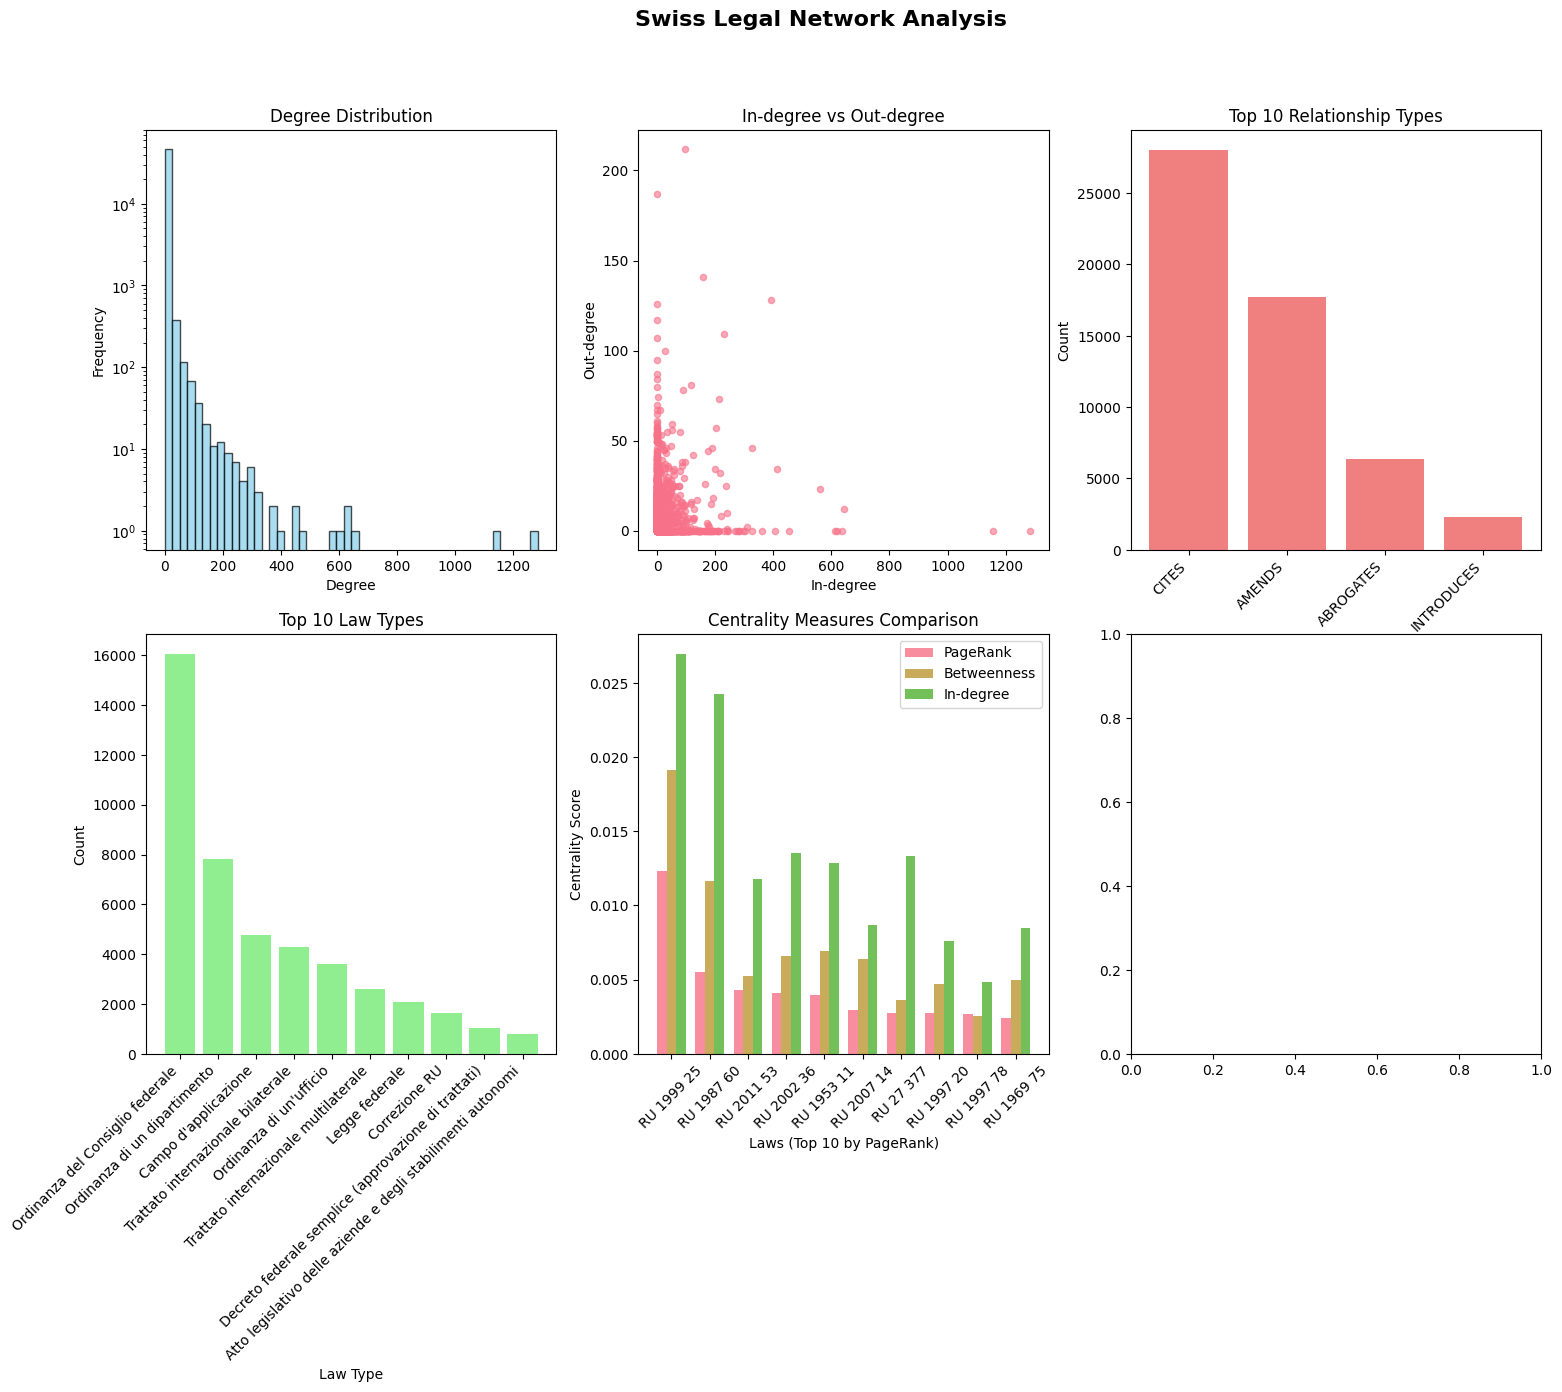

In [32]:

# Step 4: Visualizations
print("\n[4/5] Creating visualizations...")
create_visualizations(G_directed, G_undirected, centrality_results, structure_analysis)

In [33]:

# Step 5: Final Summary
print("\n[5/5] Generating comprehensive summary...")
final_results = generate_analysis_summary(structure_analysis, centrality_results, community_results, G_directed, G_undirected)

print("\n✅ Complete NetworkX analysis finished!")
print("All results are available in the 'final_results' dictionary.")


[5/5] Generating comprehensive summary...

COMPREHENSIVE NETWORK ANALYSIS SUMMARY

🏦 SWISS LEGAL NETWORK OVERVIEW:
  • Total Laws: 47,607
  • Total Legal References: 54,369
  • Network Density: 0.00002399
  • Average References per Law: 1.1
  • Average Citations per Law: 1.1

⭐ KEY NETWORK CHARACTERISTICS:
  • Network has 29756 disconnected components
  • Most influential law (PageRank): RU 1999 2556
  • Most cited law: RU 1999 2556 (1284 citations)
  • Law with most references: RU 2006 2197 (212 references)
  • Most common relationship type: CITES (28,038 instances)
  • Number of legal communities detected: 33
  • Community structure quality (modularity): 0.568

📈 NETWORK ANALYSIS INSIGHTS:
  • Network is very sparse - laws are highly specialized
  • Scale-free characteristics - few highly connected 'hub' laws

🎯 RECOMMENDATIONS FOR FURTHER ANALYSIS:
  1. Investigate the most central laws for legal system understanding
  2. Analyze community structure to identify thematic law cluster


🚀 STARTING COMPLETE NETWORKX ANALYSIS PIPELINE...

[0/6] Loading and cleaning graphs...

[1/6] Running structure analysis...

GRAPH STRUCTURE ANALYSIS

📊 BASIC METRICS:
Nodes: 47,607
Directed edges: 54,369
Undirected edges: 54,111
Directed graph density: 0.00002399
Undirected graph density: 0.00004775

📈 DEGREE STATISTICS:
Average in-degree: 1.14
Average out-degree: 1.14
Max in-degree: 1284
Max out-degree: 212
Average degree (undirected): 2.27
Max degree (undirected): 1284

🔗 CONNECTIVITY ANALYSIS:
Strongly connected components: 47232
Largest strongly connected component: 348 nodes
Weakly connected components: 29756
Largest weakly connected component: 17610 nodes
Connected components (undirected): 29756
Largest connected component: 17610 nodes

🔍 RELATIONSHIP TYPE ANALYSIS:
CITES: 28,038 (51.6%)
AMENDS: 17,698 (32.6%)
ABROGATES: 6,350 (11.7%)
INTRODUCES: 2,283 (4.2%)

⚖️ LAW TYPE ANALYSIS:
Ordinanza del Consiglio federale: 16,064 (33.7%)
Ordinanza di un dipartimento: 7,806 (16.4%)
Cam

NameError: name 'save_analysis_results' is not defined

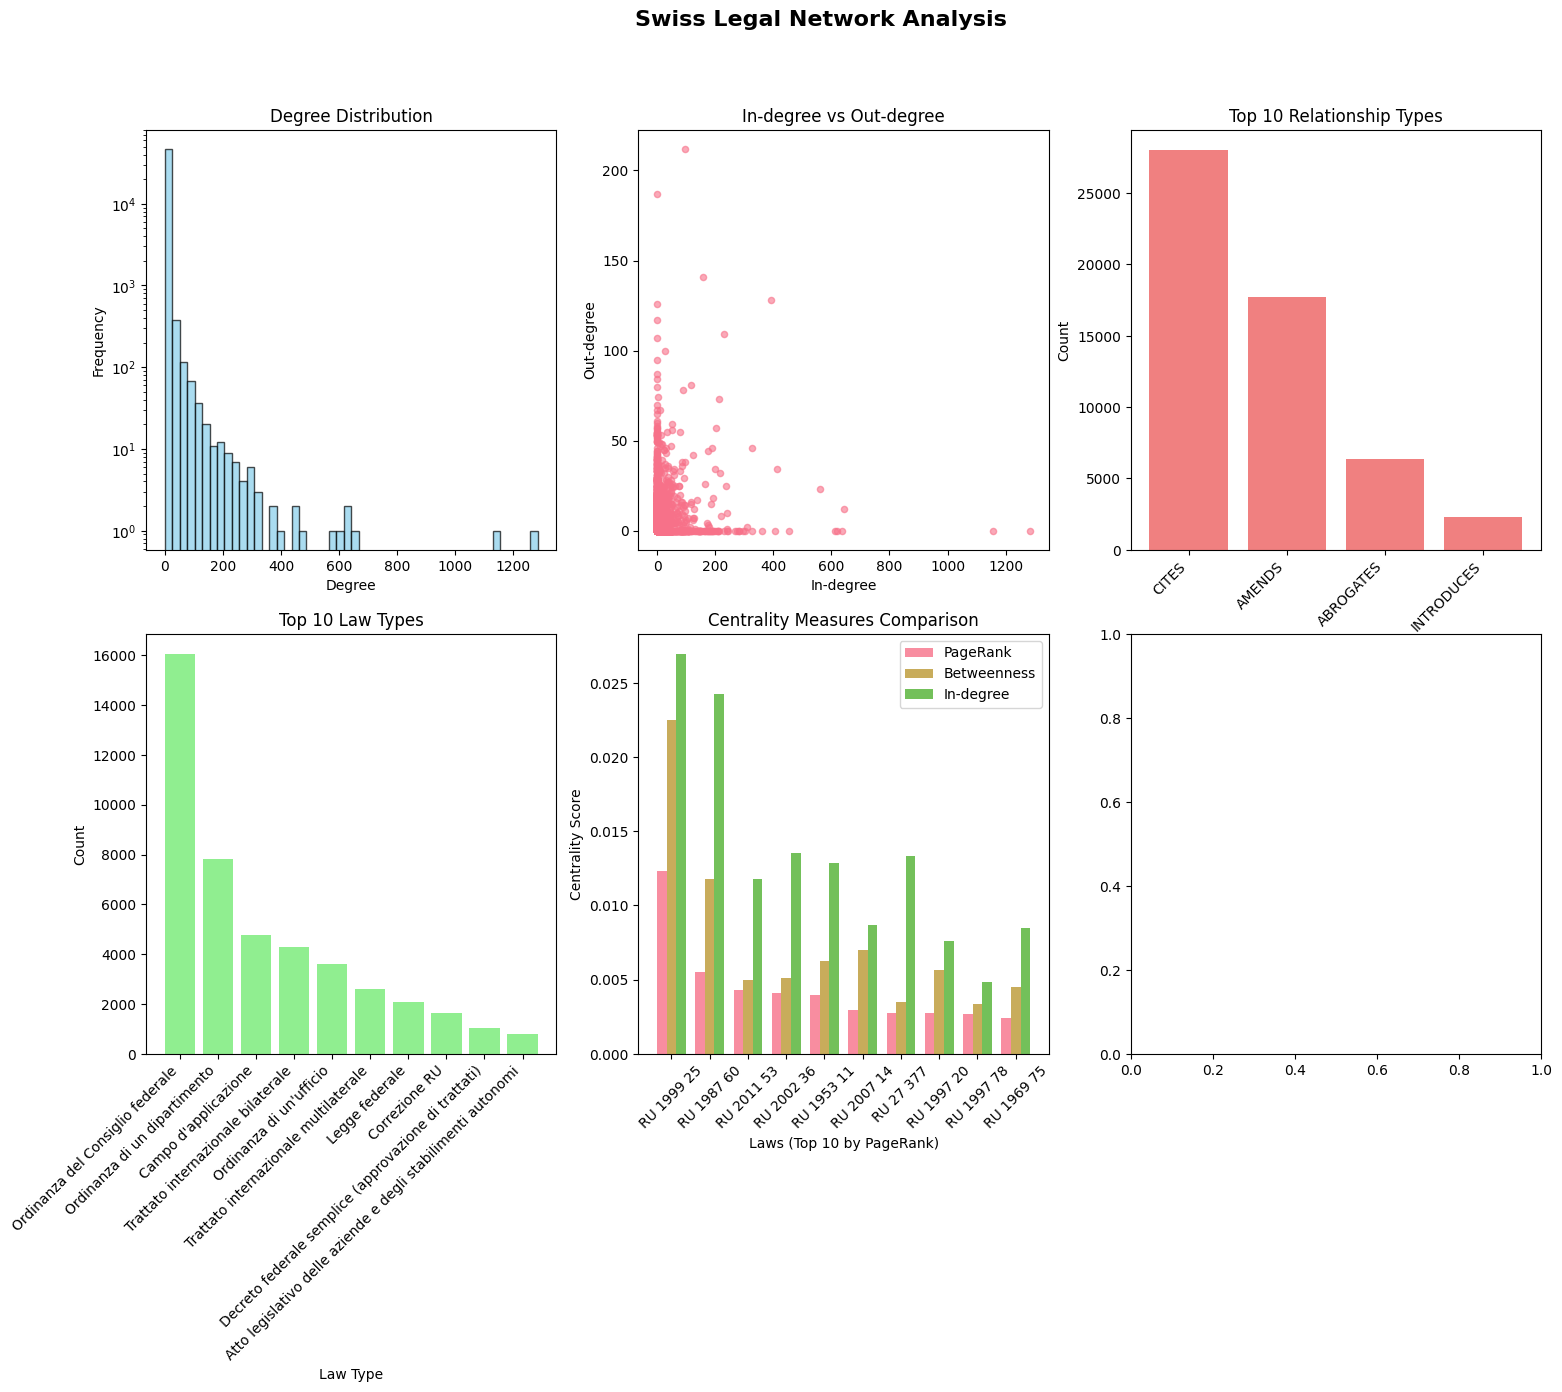

In [34]:
# Complete Analysis Pipeline with Result Saving
print("\n🚀 STARTING COMPLETE NETWORKX ANALYSIS PIPELINE...")
print("=" * 60)

# Step 0: Load and clean graphs
print("\n[0/6] Loading and cleaning graphs...")
if 'G_directed' not in locals() or 'G_undirected' not in locals():
    print("Loading graphs from pickle files...")
    with open('./raw_data/from_DB/G_directed.pickle', 'rb') as f:
        G_directed = pickle.load(f)
    with open('./raw_data/from_DB/G_undirected.pickle', 'rb') as f:
        G_undirected = pickle.load(f)
    
    # Clean graphs
    #G_directed, G_undirected = clean_graphs(G_directed, G_undirected)

# Step 1: Structure Analysis
print("\n[1/6] Running structure analysis...")
structure_analysis = analyze_graph_structure(G_directed, G_undirected)

# Step 2: Centrality Analysis
print("\n[2/6] Running centrality analysis...")
centrality_results = analyze_centrality_measures(G_directed, G_undirected)

# Step 3: Community Detection
print("\n[3/6] Running community detection...")
community_results = detect_communities(G_undirected)

# Step 4: Visualizations
print("\n[4/6] Creating visualizations...")
create_visualizations(G_directed, G_undirected, centrality_results, structure_analysis)

# Step 5: Final Summary
print("\n[5/6] Generating comprehensive summary...")
final_results = generate_analysis_summary(structure_analysis, centrality_results, community_results, G_directed, G_undirected)

# Step 6: Save All Results
print("\n[6/6] Saving all analysis results...")
analysis_manifest = save_analysis_results(
    structure_analysis=structure_analysis,
    centrality_results=centrality_results, 
    community_results=community_results,
    final_results=final_results,
    G_directed=G_directed,
    G_undirected=G_undirected
)

print("\n✅ COMPLETE NETWORKX ANALYSIS FINISHED!")
print("📊 All results are saved and available for future reference.")
print("📁 Check './raw_data/from_DB/analysis_results/' for outputs.")
print("🔗 Latest results are in the 'latest/' subdirectory for quick access.")

# Display final summary
print("\n" + "=" * 60)
print("📋 ANALYSIS SUMMARY:")
print(f"📊 Total Laws: {structure_analysis['basic_metrics']['nodes']:,}")
print(f"🔗 Total Relationships: {structure_analysis['basic_metrics']['edges']:,}")
print(f"🏘️ Communities Found: {community_results.get('louvain', {}).get('num_communities', 'N/A')}")
if 'louvain' in community_results:
    print(f"🎯 Modularity Score: {community_results['louvain'].get('modularity', 'N/A'):.4f}")
print("=" * 60)

In [ ]:
import pandas as pd
import numpy as np

def clean_graphs(G_directed, G_undirected):
    """
    Clean graphs by removing nodes with NaN or None lawId values
    """
    print("🧹 Cleaning graphs to remove invalid nodes...")
    
    # Find nodes to remove (NaN or None lawId)
    nodes_to_remove = []
    for node in G_directed.nodes():
        if node is None or pd.isna(node) or (isinstance(node, float) and np.isnan(node)):
            nodes_to_remove.append(node)
    
    print(f"Found {len(nodes_to_remove)} invalid nodes to remove")
    
    # Remove from directed graph
    G_directed.remove_nodes_from(nodes_to_remove)
    
    # Remove from undirected graph  
    G_undirected.remove_nodes_from(nodes_to_remove)
    
    print(f"After cleaning:")
    print(f"  Directed graph: {G_directed.number_of_nodes()} nodes, {G_directed.number_of_edges()} edges")
    print(f"  Undirected graph: {G_undirected.number_of_nodes()} nodes, {G_undirected.number_of_edges()} edges")
    
    return G_directed, G_undirected

# Clean the loaded graphs
G_directed, G_undirected = clean_graphs(G_directed, G_undirected)

# Test execution - run structure analysis first
print("\nTesting structure analysis...")
structure_analysis = analyze_graph_structure(G_directed, G_undirected)

: 

: 

: 

In [ ]:
import os
import json
import pickle
from datetime import datetime

def save_analysis_results(structure_analysis, centrality_results, community_results, final_results, 
                         G_directed, G_undirected, base_output_dir='./raw_data/from_DB'):
    """
    Save all analysis results in organized directories for future reference
    """
    print("\n💾 SAVING ANALYSIS RESULTS...")
    
    # Create timestamp for this analysis run
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Create output directories
    dirs_to_create = [
        f"{base_output_dir}/analysis_results",
        f"{base_output_dir}/analysis_results/structure",
        f"{base_output_dir}/analysis_results/centrality", 
        f"{base_output_dir}/analysis_results/communities",
        f"{base_output_dir}/analysis_results/graphs_cleaned",
        f"{base_output_dir}/analysis_results/summaries",
        f"{base_output_dir}/analysis_results/latest"
    ]
    
    for dir_path in dirs_to_create:
        os.makedirs(dir_path, exist_ok=True)
    
    print(f"📁 Created output directories in {base_output_dir}/analysis_results/")
    
    # 1. Save cleaned graphs
    print("\n🗃️ Saving cleaned graphs...")
    with open(f"{base_output_dir}/analysis_results/graphs_cleaned/G_directed_cleaned.pickle", 'wb') as f:
        pickle.dump(G_directed, f)
    with open(f"{base_output_dir}/analysis_results/graphs_cleaned/G_undirected_cleaned.pickle", 'wb') as f:
        pickle.dump(G_undirected, f)
    
    # Also save to latest
    with open(f"{base_output_dir}/analysis_results/latest/G_directed_cleaned.pickle", 'wb') as f:
        pickle.dump(G_directed, f)
    with open(f"{base_output_dir}/analysis_results/latest/G_undirected_cleaned.pickle", 'wb') as f:
        pickle.dump(G_undirected, f)
        
    print(f"   ✅ Saved cleaned graphs")
    
    # 2. Save structure analysis results
    print("\n📊 Saving structure analysis...")
    
    # Save basic metrics as JSON
    structure_json = {
        'basic_metrics': structure_analysis['basic_metrics'],
        'degree_statistics': structure_analysis['degree_statistics'],
        'connectivity': structure_analysis['connectivity'],
        'relationship_types': structure_analysis['relationship_types'],
        'law_types': structure_analysis['law_types'],
        'timestamp': timestamp
    }
    
    with open(f"{base_output_dir}/analysis_results/structure/structure_analysis_{timestamp}.json", 'w') as f:
        json.dump(structure_json, f, indent=2, default=str)
    
    with open(f"{base_output_dir}/analysis_results/latest/structure_analysis.json", 'w') as f:
        json.dump(structure_json, f, indent=2, default=str)
    
    # Save degree sequences as pickle for later analysis
    degree_data = {
        'in_degree_sequence': structure_analysis['degree_sequences']['in_degree'],
        'out_degree_sequence': structure_analysis['degree_sequences']['out_degree'],
        'undirected_degree_sequence': structure_analysis['degree_sequences']['undirected_degree']
    }
    
    with open(f"{base_output_dir}/analysis_results/structure/degree_sequences_{timestamp}.pickle", 'wb') as f:
        pickle.dump(degree_data, f)
    
    with open(f"{base_output_dir}/analysis_results/latest/degree_sequences.pickle", 'wb') as f:
        pickle.dump(degree_data, f)
        
    print(f"   ✅ Saved structure analysis")
    
    # 3. Save centrality results
    print("\n🎯 Saving centrality analysis...")
    
    # Convert centrality results to JSON-serializable format
    centrality_json = {
        'summary_stats': centrality_results['summary_stats'],
        'timestamp': timestamp
    }
    
    # Save top rankings
    rankings_data = {}
    for measure in ['in_degree', 'out_degree', 'pagerank', 'betweenness']:
        if f'top_{measure}' in centrality_results:
            rankings_data[f'top_{measure}'] = centrality_results[f'top_{measure}']
    
    centrality_json['top_rankings'] = rankings_data
    
    with open(f"{base_output_dir}/analysis_results/centrality/centrality_analysis_{timestamp}.json", 'w') as f:
        json.dump(centrality_json, f, indent=2, default=str)
    
    with open(f"{base_output_dir}/analysis_results/latest/centrality_analysis.json", 'w') as f:
        json.dump(centrality_json, f, indent=2, default=str)
    
    # Save full centrality scores as pickle
    centrality_scores = {}
    for measure in ['in_degree_centrality', 'out_degree_centrality', 'pagerank', 'betweenness_centrality']:
        if measure in centrality_results:
            centrality_scores[measure] = centrality_results[measure]
    
    with open(f"{base_output_dir}/analysis_results/centrality/centrality_scores_{timestamp}.pickle", 'wb') as f:
        pickle.dump(centrality_scores, f)
    
    with open(f"{base_output_dir}/analysis_results/latest/centrality_scores.pickle", 'wb') as f:
        pickle.dump(centrality_scores, f)
        
    print(f"   ✅ Saved centrality analysis")
    
    # 4. Save community detection results
    print("\n🏘️ Saving community analysis...")
    
    # Prepare community results for JSON serialization
    community_json = {
        'timestamp': timestamp
    }
    
    # Handle different community detection methods
    for method in ['louvain', 'greedy']:
        if method in community_results:
            method_data = community_results[method].copy()
            
            # Convert partition to JSON-serializable format if it exists
            if 'partition' in method_data:
                # Convert partition dict to list of [node, community] pairs
                method_data['partition_list'] = [[str(node), int(comm)] for node, comm in method_data['partition'].items()]
                del method_data['partition']  # Remove the original dict
            
            # Convert community lists to serializable format if they exist
            if 'communities' in method_data:
                method_data['communities_list'] = [list(map(str, community)) for community in method_data['communities']]
                del method_data['communities']  # Remove the original list of sets
            
            community_json[method] = method_data
    
    with open(f"{base_output_dir}/analysis_results/communities/community_analysis_{timestamp}.json", 'w') as f:
        json.dump(community_json, f, indent=2, default=str)
    
    with open(f"{base_output_dir}/analysis_results/latest/community_analysis.json", 'w') as f:
        json.dump(community_json, f, indent=2, default=str)
    
    # Save full community results as pickle
    with open(f"{base_output_dir}/analysis_results/communities/community_results_{timestamp}.pickle", 'wb') as f:
        pickle.dump(community_results, f)
    
    with open(f"{base_output_dir}/analysis_results/latest/community_results.pickle", 'wb') as f:
        pickle.dump(community_results, f)
        
    print(f"   ✅ Saved community analysis")
    
    # 5. Save comprehensive summary
    print("\n📋 Saving comprehensive summary...")
    
    # Convert final results to JSON-serializable format
    summary_json = {
        'analysis_metadata': {
            'timestamp': timestamp,
            'total_laws': final_results.get('total_laws', 0),
            'total_relationships': final_results.get('total_relationships', 0),
            'analysis_date': datetime.now().isoformat()
        },
        'key_insights': final_results.get('insights', []),
        'recommendations': final_results.get('recommendations', [])
    }
    
    with open(f"{base_output_dir}/analysis_results/summaries/comprehensive_summary_{timestamp}.json", 'w') as f:
        json.dump(summary_json, f, indent=2, default=str)
    
    with open(f"{base_output_dir}/analysis_results/latest/comprehensive_summary.json", 'w') as f:
        json.dump(summary_json, f, indent=2, default=str)
    
    # Save full final results as pickle
    with open(f"{base_output_dir}/analysis_results/summaries/final_results_{timestamp}.pickle", 'wb') as f:
        pickle.dump(final_results, f)
    
    with open(f"{base_output_dir}/analysis_results/latest/final_results.pickle", 'wb') as f:
        pickle.dump(final_results, f)
        
    print(f"   ✅ Saved comprehensive summary")
    
    # 6. Create analysis manifest
    print("\n📝 Creating analysis manifest...")
    
    manifest = {
        'analysis_info': {
            'timestamp': timestamp,
            'analysis_date': datetime.now().isoformat(),
            'graphs': {
                'directed_nodes': G_directed.number_of_nodes(),
                'directed_edges': G_directed.number_of_edges(),
                'undirected_nodes': G_undirected.number_of_nodes(),
                'undirected_edges': G_undirected.number_of_edges()
            }
        },
        'files_created': {
            'structure_analysis': f"structure/structure_analysis_{timestamp}.json",
            'centrality_analysis': f"centrality/centrality_analysis_{timestamp}.json",
            'community_analysis': f"communities/community_analysis_{timestamp}.json",
            'comprehensive_summary': f"summaries/comprehensive_summary_{timestamp}.json",
            'cleaned_graphs': {
                'directed': "graphs_cleaned/G_directed_cleaned.pickle",
                'undirected': "graphs_cleaned/G_undirected_cleaned.pickle"
            }
        },
        'latest_files': {
            'structure_analysis': "latest/structure_analysis.json",
            'centrality_analysis': "latest/centrality_analysis.json", 
            'community_analysis': "latest/community_analysis.json",
            'comprehensive_summary': "latest/comprehensive_summary.json"
        }
    }
    
    with open(f"{base_output_dir}/analysis_results/analysis_manifest_{timestamp}.json", 'w') as f:
        json.dump(manifest, f, indent=2)
    
    with open(f"{base_output_dir}/analysis_results/latest/analysis_manifest.json", 'w') as f:
        json.dump(manifest, f, indent=2)
        
    print(f"   ✅ Created analysis manifest")
    
    print(f"\n🎉 ALL RESULTS SAVED SUCCESSFULLY!")
    print(f"📍 Results location: {base_output_dir}/analysis_results/")
    print(f"📍 Latest results: {base_output_dir}/analysis_results/latest/")
    print(f"📍 Timestamped results: {base_output_dir}/analysis_results/*_{timestamp}.*")
    
    return manifest

: 

: 

: 

: 

In [ ]:
def load_saved_analysis_results(base_output_dir='./raw_data/from_DB'):
    """
    Load previously saved analysis results from the latest directory
    """
    print("💾 LOADING SAVED ANALYSIS RESULTS...")
    
    latest_dir = f"{base_output_dir}/analysis_results/latest"
    
    if not os.path.exists(latest_dir):
        print(f"❌ No saved results found in {latest_dir}")
        return None
    
    results = {}
    
    try:
        # Load cleaned graphs
        print("🗃️ Loading cleaned graphs...")
        with open(f"{latest_dir}/G_directed_cleaned.pickle", 'rb') as f:
            results['G_directed'] = pickle.load(f)
        with open(f"{latest_dir}/G_undirected_cleaned.pickle", 'rb') as f:
            results['G_undirected'] = pickle.load(f)
        print(f"   ✅ Loaded graphs: {results['G_directed'].number_of_nodes()} nodes, {results['G_directed'].number_of_edges()} edges")
        
        # Load structure analysis
        print("📊 Loading structure analysis...")
        with open(f"{latest_dir}/structure_analysis.json", 'r') as f:
            results['structure_analysis_json'] = json.load(f)
        with open(f"{latest_dir}/degree_sequences.pickle", 'rb') as f:
            results['degree_sequences'] = pickle.load(f)
        print("   ✅ Loaded structure analysis")
        
        # Load centrality analysis
        print("🎯 Loading centrality analysis...")
        with open(f"{latest_dir}/centrality_analysis.json", 'r') as f:
            results['centrality_analysis_json'] = json.load(f)
        with open(f"{latest_dir}/centrality_scores.pickle", 'rb') as f:
            results['centrality_scores'] = pickle.load(f)
        print("   ✅ Loaded centrality analysis")
        
        # Load community analysis
        print("🏘️ Loading community analysis...")
        with open(f"{latest_dir}/community_analysis.json", 'r') as f:
            results['community_analysis_json'] = json.load(f)
        with open(f"{latest_dir}/community_results.pickle", 'rb') as f:
            results['community_results'] = pickle.load(f)
        print("   ✅ Loaded community analysis")
        
        # Load comprehensive summary
        print("📋 Loading comprehensive summary...")
        with open(f"{latest_dir}/comprehensive_summary.json", 'r') as f:
            results['comprehensive_summary'] = json.load(f)
        with open(f"{latest_dir}/final_results.pickle", 'rb') as f:
            results['final_results'] = pickle.load(f)
        print("   ✅ Loaded comprehensive summary")
        
        # Load analysis manifest
        with open(f"{latest_dir}/analysis_manifest.json", 'r') as f:
            results['manifest'] = json.load(f)
        
        print(f"\n🎉 ALL RESULTS LOADED SUCCESSFULLY!")
        print(f"📅 Analysis date: {results['manifest']['analysis_info']['analysis_date']}")
        print(f"📏 Available data:")
        for key in results.keys():
            if key not in ['manifest']:
                print(f"   - {key}")
        
        return results
        
    except FileNotFoundError as e:
        print(f"❌ Error loading results: {e}")
        print(f"📝 Run the complete analysis first to generate results.")
        return None
    except Exception as e:
        print(f"❌ Unexpected error loading results: {e}")
        return None

print("📁 Result loading function ready. Use: loaded_results = load_saved_analysis_results()")

: 

: 

: 

## Quick Access to Analysis Results

This section provides functions to save and load analysis results for future reference without re-running the entire analysis.

In [ ]:
# Example: Load saved results instead of re-running analysis
# Uncomment the following lines to load previously saved results:

# loaded_results = load_saved_analysis_results()
# if loaded_results:
#     G_directed = loaded_results['G_directed']
#     G_undirected = loaded_results['G_undirected']
#     structure_analysis = loaded_results['structure_analysis_json']
#     centrality_results = loaded_results['centrality_scores']
#     community_results = loaded_results['community_results']
#     final_results = loaded_results['final_results']
#     
#     print("\n📊 Quick Summary from Loaded Results:")
#     print(f"🏛️ Total Laws: {structure_analysis['basic_metrics']['nodes']:,}")
#     print(f"🔗 Total Relationships: {structure_analysis['basic_metrics']['edges']:,}")
#     print(f"📅 Analysis Date: {loaded_results['manifest']['analysis_info']['analysis_date']}")
#     
#     # Access top laws by centrality
#     if 'top_rankings' in loaded_results['centrality_analysis_json']:
#         print("\n🎯 Top Laws by PageRank:")
#         top_pagerank = loaded_results['centrality_analysis_json']['top_rankings'].get('top_pagerank', [])
#         for i, (law_id, score) in enumerate(top_pagerank[:5], 1):
#             print(f"  {i}. {law_id}: {score:.6f}")
print("📝 Example code ready - uncomment lines above to load saved results")

: 

: 

: 

In [ ]:
# Check what analysis results are available
results_base_dir = './raw_data/from_DB/analysis_results'

if os.path.exists(results_base_dir):
    print(f"📂 Analysis results directory exists: {results_base_dir}")
    
    # Check for latest results
    latest_dir = f"{results_base_dir}/latest"
    if os.path.exists(latest_dir):
        print(f"\n📋 Latest analysis results available:")
        latest_files = os.listdir(latest_dir)
        for file in sorted(latest_files):
            file_path = os.path.join(latest_dir, file)
            if os.path.isfile(file_path):
                size_mb = os.path.getsize(file_path) / 1024 / 1024
                print(f"  ✅ {file} ({size_mb:.2f} MB)")
        
        # Check manifest for analysis info
        manifest_path = f"{latest_dir}/analysis_manifest.json"
        if os.path.exists(manifest_path):
            with open(manifest_path, 'r') as f:
                manifest = json.load(f)
            print(f"\n📊 Latest Analysis Info:")
            print(f"  📅 Date: {manifest['analysis_info']['analysis_date']}")
            print(f"  🏛️ Nodes: {manifest['analysis_info']['graphs']['directed_nodes']:,}")
            print(f"  🔗 Edges: {manifest['analysis_info']['graphs']['directed_edges']:,}")
    else:
        print(f"\n⚠️ No latest results found. Run the complete analysis first.")
    
    # List timestamped analyses
    timestamped_files = [f for f in os.listdir(results_base_dir) if f.startswith('analysis_manifest_')]
    if timestamped_files:
        print(f"\n📚 Available historical analyses: {len(timestamped_files)}")
        for manifest_file in sorted(timestamped_files)[-3:]:  # Show last 3
            timestamp = manifest_file.replace('analysis_manifest_', '').replace('.json', '')
            print(f"  📅 {timestamp}")
else:
    print(f"❌ No analysis results directory found at {results_base_dir}")
    print(f"🔄 Run the complete analysis pipeline to generate results.")

: 

: 

: 

### Saved Results Structure

The analysis results are saved in `./raw_data/from_DB/analysis_results/` with the following structure:

```
analysis_results/
├── latest/                          # Most recent analysis (for quick access)
│   ├── G_directed_cleaned.pickle    # Cleaned directed graph
│   ├── G_undirected_cleaned.pickle  # Cleaned undirected graph
│   ├── structure_analysis.json      # Basic graph structure metrics
│   ├── centrality_analysis.json     # Centrality measures and rankings
│   ├── community_analysis.json      # Community detection results
│   ├── comprehensive_summary.json   # Overall analysis summary
│   └── analysis_manifest.json       # Analysis metadata
├── graphs_cleaned/                  # Cleaned graph files
├── structure/                       # Structure analysis results
├── centrality/                      # Centrality analysis results
├── communities/                     # Community detection results
├── summaries/                       # Comprehensive summaries
└── analysis_manifest_YYYYMMDD_HHMMSS.json  # Timestamped manifests
```

**File Types:**
- `.json` files: Human-readable summaries and key results
- `.pickle` files: Full Python objects for detailed analysis
- `latest/` directory: Always contains the most recent analysis for quick access